# Semantic Log Debugger & Causal RCA Pipeline
This notebook implements a Cognitive Software Debugger for HDFS logs using:
1. **Semantic Vector Embeddings** (Sentence-Transformers)
2. **Vector Similarity Search** (FAISS)
3. **Causal Dependency Graphs** (NetworkX)

### Setup & Configurations

In [1]:
# INSTALL PROJECT DEPENDENCIES
# This cell installs all required AI and visualization libraries from requirements.txt.
import sys
print("Installing dependencies from requirements.txt...")
!{sys.executable} -m pip install -r requirements.txt --quiet

print("\n--- INSTALLATION COMPLETE ---")
print("ACTION: If you updated libraries, please RESTART THE KERNEL!")

Installing dependencies from requirements.txt...

--- INSTALLATION COMPLETE ---
ACTION: If you updated libraries, please RESTART THE KERNEL!



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
import re
import json
import random
import sys
import subprocess
import pandas as pd
import numpy as np
import faiss
import networkx as nx
import torch
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm.notebook import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer

try:
    from sentence_transformers import SentenceTransformer
except Exception:
    SentenceTransformer = None

from pyvis.network import Network
from IPython.display import display, IFrame

# Directory Setup
INPUT_DIR = "dataset"
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# File Paths
DATASET_FILE = os.path.join(INPUT_DIR, "HDFS_2k.log_structured.csv")
TRACES_FILE = os.path.join(OUTPUT_DIR, "structured_traces.json")
TEMPLATES_FILE = os.path.join(OUTPUT_DIR, "extracted_templates.json")
RCA_RESULTS_FILE = os.path.join(OUTPUT_DIR, "rca_results.json")
ANOMALIES_FILE = os.path.join(OUTPUT_DIR, "anomalous_traces.json")
FAISS_INDEX_FILE = os.path.join(OUTPUT_DIR, "faiss_index.bin")
MAPPING_FILE = os.path.join(OUTPUT_DIR, "template_mapping.json")

print("Project initialized with dataset and output directories.")
rca_results = {}

Project initialized with dataset and output directories.


## Stage 1: Data Preprocessing
Loading the structured dataset and grouping logs by `block_id`.

In [2]:
def extract_block_id(content):
    match = re.search(r'(blk_-?\d+)', str(content))
    return match.group(1) if match else None

print(f"Loading dataset: {DATASET_FILE}")
df = pd.read_csv(DATASET_FILE)

print("\n--- Sample Dataset Record ---")
display(df.head())

traces = defaultdict(list)
templates_set = set()

for _, row in tqdm(df.iterrows(), total=len(df), desc="Grouping Logs"):
    block_id = extract_block_id(row['Content'])
    if block_id:
        traces[block_id].append(row['EventTemplate'])
        templates_set.add(row['EventTemplate'])

templates_dict = {str(i): t for i, t in enumerate(sorted(list(templates_set)))}
rev_map = {t: i for i, t in templates_dict.items()}
structured_traces = {b_id: [rev_map[t] for t in seq] for b_id, seq in traces.items()}

with open(TRACES_FILE, 'w') as f: json.dump(structured_traces, f)
with open(TEMPLATES_FILE, 'w') as f: json.dump(templates_dict, f)
print(f"\nPreprocessed {len(structured_traces)} traces and {len(templates_dict)} templates.")

Loading dataset: dataset\HDFS_2k.log_structured.csv

--- Sample Dataset Record ---


,LineId,Date,Time,Pid,Level,Component,Content,EventId,EventTemplate
0,1,81109,203615,148,INFO,dfs.DataNode$PacketResponder,PacketResponder 1 for block blk_38865049064139...,E10,PacketResponder <*> for block blk_<*> terminating
1,2,81109,203807,222,INFO,dfs.DataNode$PacketResponder,PacketResponder 0 for block blk_-6952295868487...,E10,PacketResponder <*> for block blk_<*> terminating
2,3,81109,204005,35,INFO,dfs.FSNamesystem,BLOCK* NameSystem.addStoredBlock: blockMap upd...,E6,BLOCK* NameSystem.addStoredBlock: blockMap upd...
3,4,81109,204015,308,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_82291938032499...,E10,PacketResponder <*> for block blk_<*> terminating
4,5,81109,204106,329,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_-6670958622368...,E10,PacketResponder <*> for block blk_<*> terminating


Grouping Logs:   0%|          | 0/2000 [00:00<?, ?it/s]


Preprocessed 1994 traces and 14 templates.


## Stage 2: Semantic Vector Embedding
Converting templates into dense vectors using MiniLM and storing in FAISS.

In [3]:
print("Loading Transformer Embedding Model...")
model = None
model_name = None

if SentenceTransformer is not None:
    candidate_models = [
        "all-mpnet-base-v2",
        "all-MiniLM-L6-v2",
        "paraphrase-mpnet-base-v2",
        "all-MiniLM-L12-v2"
    ]
    for candidate in candidate_models:
        try:
            print(f"Trying embedding model: {candidate}")
            model = SentenceTransformer(candidate)
            model_name = candidate
            print(f"Loaded embedding model: {candidate}")
            break
        except Exception as e:
            print(f"Model {candidate} failed: {e}")

if model is None:
    print("No SentenceTransformer embedding model loaded. Falling back to TF-IDF embeddings.")

template_texts = list(templates_dict.values())
template_ids = list(templates_dict.keys())

if model is not None:
    embeddings = model.encode(template_texts, show_progress_bar=True, convert_to_numpy=True).astype('float32')
else:
    vectorizer = TfidfVectorizer(max_features=768, stop_words='english', ngram_range=(1,2))
    embeddings = vectorizer.fit_transform(template_texts).toarray().astype('float32')

faiss.normalize_L2(embeddings)

index = faiss.IndexFlatL2(embeddings.shape[1])
index.add(embeddings)
faiss.write_index(index, FAISS_INDEX_FILE)

with open(MAPPING_FILE, 'w') as f:
    json.dump({i: t_id for i, t_id in enumerate(template_ids)}, f)

print("FAISS index and mappings saved to output folder.")
if model_name is not None:
    print(f"Using embedding model: {model_name}")
else:
    print("Using TF-IDF fallback embedding.")

Loading Transformer Embedding Model...
No SentenceTransformer embedding model loaded. Falling back to TF-IDF embeddings.
FAISS index and mappings saved to output folder.
Using TF-IDF fallback embedding.


## Stage 3: Semantic Anomaly Detection
Identifying 'Error' or 'Malicious' logs by semantic meaning.

In [4]:
# 1. Define semantic error categories
ERROR_QUERIES = ["Connection timeout", "Network exception", "Block missing/corrupted", "Fatal error"]

if model is not None:
    query_embeddings = model.encode(ERROR_QUERIES, convert_to_numpy=True).astype('float32')
else:
    query_embeddings = vectorizer.transform(ERROR_QUERIES).toarray().astype('float32')

faiss.normalize_L2(query_embeddings)

# 2. Search for similar logs (Threshold: Distance < 1.3)
distances, indices = index.search(query_embeddings, k=5)
with open(MAPPING_FILE) as f: idx_to_tid = {int(k): v for k, v in json.load(f).items()}

# Track which query matched which template
error_mapping = {} # template_id -> list of categories
for i, query in enumerate(ERROR_QUERIES):
    for j in range(5):
        if distances[i][j] < 1.3:
            t_id = idx_to_tid[indices[i][j]]
            if t_id not in error_mapping: error_mapping[t_id] = []
            error_mapping[t_id].append(query)

anomalous_ids = set(error_mapping.keys())

# 3. Label traces
anomalies = {b_id: {"seq": seq, "errs": list(set(seq).intersection(anomalous_ids))} 
             for b_id, seq in structured_traces.items() if set(seq).intersection(anomalous_ids)}

with open(ANOMALIES_FILE, 'w') as f: json.dump(anomalies, f)

# 4. Display Analysis Summary
print(f"Basis for Labeling: Semantic similarity to known error patterns (Distance < 1.3)")
print(f"Detected {len(anomalies)} anomalous traces involving {len(anomalous_ids)} distinct error templates.\n")

summary_data = []
for t_id, categories in error_mapping.items():
    count = sum(seq.count(t_id) for seq in structured_traces.values())
    summary_data.append({
        "Error Category": ", ".join(categories),
        "Log Template": templates_dict[t_id],
        "Occurrences": count
    })

df_summary = pd.DataFrame(summary_data)
if not df_summary.empty:
    display(df_summary.groupby("Error Category").agg({
        "Occurrences": "sum", 
        "Log Template": "count"
    }).rename(columns={"Log Template": "Unique Templates"}))
else:
    print("No errors detected with current threshold.")

Basis for Labeling: Semantic similarity to known error patterns (Distance < 1.3)
Detected 281 anomalous traces involving 5 distinct error templates.



,Occurrences,Unique Templates
Error Category,,
"Connection timeout, Fatal error",201,4
"Connection timeout, Network exception, Fatal error",80,1


## Stage 4: Causal Dependency Graph & RCA
We build a Directed Acyclic Graph (DAG) for each trace to find the root cause of failures.

In [5]:
def perform_rca(b_id, content):
    seq = content['seq']
    err_ids = content['errs']
    G = nx.DiGraph()
    for i in range(len(seq)-1): G.add_edge(seq[i], seq[i+1])
    try:
        scores = nx.pagerank(G)
        rc_id = max(scores, key=scores.get)
    except: rc_id = seq[0]
    return {"sequence": seq, "err_ids": err_ids, "rc_id": rc_id, "explanation": "Root cause identified via PageRank analysis of causal dependencies."}

print(f"Analyzing {len(anomalies)} anomalous traces...")
rca_results = {b_id: perform_rca(b_id, data) for b_id, data in anomalies.items()}
with open(RCA_RESULTS_FILE, 'w') as f: json.dump(rca_results, f)
print(f"RCA completed. Results saved to {RCA_RESULTS_FILE}")

Analyzing 281 anomalous traces...
RCA completed. Results saved to outputs\rca_results.json


## Stage 5: Interactive RCA Visualization
Visualizing the causal dependency graphs and anomaly patterns.


--- RCA Results Summary ---


,Root Cause Template ID,Occurrences,Template
0,4,114,BLOCK* NameSystem.allocateBlock: /<*>/part-<*>...
1,0,80,<*>:<*> Served block blk_<*> to /<*>
2,2,80,<*>:<*>:Got exception while serving blk_<*> to...
3,6,5,BLOCK* ask <*>:<*> to delete blk_<*>
4,1,1,<*>:<*> Starting thread to transfer block blk_...
5,12,1,Receiving block blk_<*> src: /<*>:<*> dest: /<...


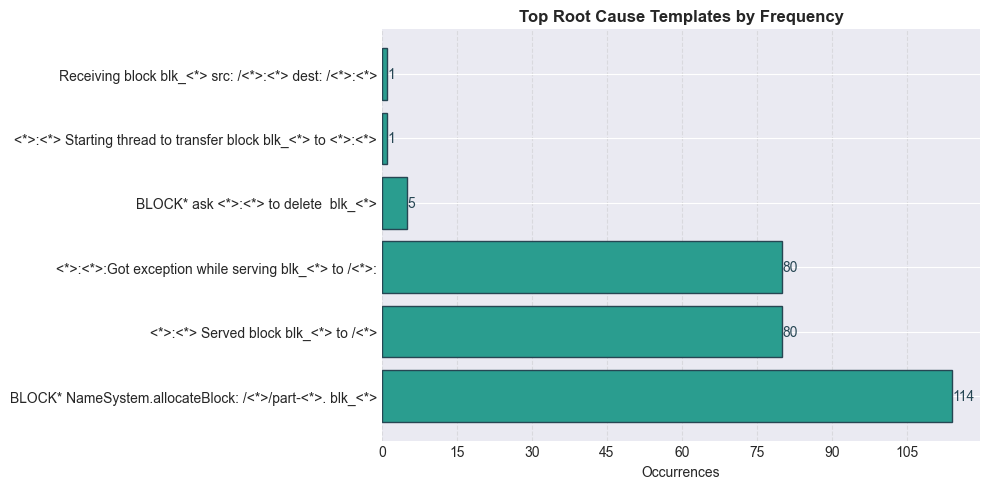

c:\1Data\Ved_Data\AmritaCSE\FinalYearProject\FinalYearProject\outputs\rca_graph_all.html
Receiving block blk_<*> src: /<*>:<*> dest: /<*>:<*> saved to: c:\1Data\Ved_Data\AmritaCSE\FinalYearProject\FinalYearProject\outputs\rca_graph_all.html
c:\1Data\Ved_Data\AmritaCSE\FinalYearProject\FinalYearProject\outputs\rca_graph_root_causes.html
BLOCK* NameSystem.allocateBlock: /<*>/part-<*>. blk_<*> saved to: c:\1Data\Ved_Data\AmritaCSE\FinalYearProject\FinalYearProject\outputs\rca_graph_root_causes.html
--- Error Log Files with Root Causes ---
Block ID: blk_-1727475099218615100
  Root Cause: [4] BLOCK* NameSystem.allocateBlock: /<*>/part-<*>. blk_<*>
  Error Templates: [4] BLOCK* NameSystem.allocateBlock: /<*>/part-<*>. blk_<*>

Block ID: blk_-7878121102358435702
  Root Cause: [4] BLOCK* NameSystem.allocateBlock: /<*>/part-<*>. blk_<*>
  Error Templates: [4] BLOCK* NameSystem.allocateBlock: /<*>/part-<*>. blk_<*>

Block ID: blk_-5319073033164653435
  Root Cause: [4] BLOCK* NameSystem.allocateB

In [6]:
from collections import Counter
from matplotlib.ticker import MaxNLocator

print("\n--- RCA Results Summary ---")
if rca_results:
    root_counts = Counter(result['rc_id'] for result in rca_results.values())
    root_summary = pd.DataFrame([
        {"Root Cause Template ID": rc_id, "Occurrences": count, "Template": templates_dict[str(rc_id)]}
        for rc_id, count in root_counts.most_common()
    ])
    display(root_summary.head(10))

    # Plot root cause frequency with improved styling
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.figure(figsize=(10, 5))
    top_n = 10
    top_summary = root_summary.head(top_n).iloc[::-1]
    bars = plt.barh(top_summary['Template'], top_summary['Occurrences'], color='#2a9d8f', edgecolor='#264653')
    plt.xlabel('Occurrences')
    plt.title('Top Root Cause Templates by Frequency', fontweight='bold')
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.grid(axis='x', color='#bbbbbb', alpha=0.35, linestyle='--')
    for bar in bars:
        plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2, str(int(bar.get_width())), va='center', color='#264653')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("No anomalous traces detected. Showing all logs in the visual graph.")

# Build interactive RCA graph with enhanced styling
def build_rca_graph(filtered_b_ids, title, filename):
    net = Network(height='750px', width='100%', directed=True, notebook=True)
    net.set_options('''{
  "nodes": {
    "shape": "dot",
    "font": {"size": 14, "face": "Arial"},
    "borderWidth": 2,
    "color": {"highlight": {"border": "#2a9d8f", "background": "#e9c46a"}}
  },
  "edges": {
    "color": {"inherit": false, "color": "#6c757d"},
    "smooth": {"enabled": true, "type": "cubicBezier", "roundness": 0.25},
    "arrows": {"to": {"enabled": true, "scaleFactor": 0.7}}
  },
  "physics": {
    "enabled": true,
    "barnesHut": {"gravitationalConstant": -25000, "centralGravity": 0.35, "springLength": 150, "springConstant": 0.04, "damping": 0.08},
    "minVelocity": 0.75
  }
}''')

    if not filtered_b_ids:
        print(f'No traces to render for {title}.')
        return

    for b_id in filtered_b_ids:
        seq = structured_traces.get(b_id, [])
        err_ids = set()
        rc_id = None
        if b_id in rca_results:
            err_ids = set(rca_results[b_id].get('err_ids', []))
            rc_id = rca_results[b_id].get('rc_id')

        for idx, node_id in enumerate(seq):
            label = templates_dict[str(node_id)] if str(node_id) in templates_dict else f"Template {node_id}"
            title = label
            if node_id == rc_id and node_id in err_ids:
                color = '#d62828'
                border_color = '#8b0000'
                size = 80
                label = f"ROOT ERROR\n{label}"
            elif node_id == rc_id:
                color = '#2a9d8f'
                border_color = '#1f7a5f'
                size = 65
                label = f"ROOT\n{label}"
            elif node_id in err_ids:
                color = '#d62828'
                border_color = '#8b0000'
                size = 70
                label = f"ERROR\n{label}"
            else:
                color = '#2a9d8f'
                border_color = '#1f7a5f'
                size = 35
                label = f"STEP\n{label}"
            shape = 'dot'
            net.add_node(
                f"{b_id}_{node_id}_{idx}",
                label=label,
                title=title,
                color={"border": border_color, "background": color},
                size=size,
                shape=shape
            )
            if idx > 0:
                prev = f"{b_id}_{seq[idx-1]}_{idx-1}"
                current = f"{b_id}_{node_id}_{idx}"
                net.add_edge(prev, current)

    output_path = os.path.abspath(os.path.join(OUTPUT_DIR, filename))
    net.show(output_path)
    print(f'{title} saved to: {output_path}')

# Generate three RCA visualizations:
all_ids = list(structured_traces.keys())
error_only_ids = [b_id for b_id, data in rca_results.items() if data.get('err_ids')]
root_cause_ids = [b_id for b_id, data in rca_results.items() if data.get('rc_id') is not None]

build_rca_graph(all_ids, 'All Logs RCA Graph', 'rca_graph_all.html')
build_rca_graph(root_cause_ids, 'Root Cause-only RCA Graph', 'rca_graph_root_causes.html')


print('--- Error Log Files with Root Causes ---')
if rca_results:
    for b_id, result in rca_results.items():
        err_ids = result.get('err_ids', [])
        rc_id = result.get('rc_id')
        root_template = templates_dict.get(str(rc_id), f"Template {rc_id}") if rc_id is not None else 'Unknown'
        error_template_strings = [f'[{e}] {templates_dict.get(str(e), f"Template {e}")}' for e in err_ids]
        error_templates_str = ', '.join(error_template_strings)
        print(f'Block ID: {b_id}')
        print(f'  Root Cause: [{rc_id}] {root_template}')
        print(f'  Error Templates: {error_templates_str}')
        print('')
else:
    print('No error logs or root cause mappings found.')
